# Supplementary Figure S48: `s48_predicting_cv_trained`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_predicting_cv_trained.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Among the nine trained models (225 encoding axes), what predicts held-out parametric control? The figure pits gradient spectral PR (top row) against adversarial sensitivity (bottom row), each alongside natural-image encoding accuracy. Panels a and d give 10-fold cross-validated R squared for the row's predictor alone, encoding accuracy alone, and both together, against a split-half ceiling. Panels b and e test the row's predictor alone under progressively harder held-out regimes: random folds, whole models, whole sites, whole animals. Panels c and f scatter measured against predicted control slope with the model itself held out. Inputs are `L.control_table()`, the frozen `sup_predicting_master.csv` (encoding accuracy and adversarial sensitivity) and the held-out gradient profiles in `fig5_heldout_gradfreq`. Untrained is excluded because it is an out-of-distribution extreme that inflates every correlation and breaks leave-one-model-out on the residualized outcome.

## What the script says about itself

Supp. Fig. (slug predicting_cv_trained) -- what predicts HELD-OUT parametric control among the trained models: gradient spectral concentration (top row) versus adversarial sensitivity (bottom row), each against natural-image encoding accuracy.

Scope: the 9 TRAINED models x 25 sites (225 encoding axes). The untrained control is excluded -- it is an out-of-distribution extreme that inflates every correlation and breaks leave-one-model-out on the site-residualized outcome.

Outcome: control slope and control r, each site-residualized against the per-site mean over the 9 trained models (the main-figure residual). Predictors: gradient spectral participation ratio on the 100 held-out natural images and first-order adversarial sensitivity (both main-figure quantities), plus the calibration-phase encoding test r. Models are ordinary least squares with a single global slope per predictor (no per-animal terms -- the only design under which an unseen animal can be predicted at all), z-scored within each training fold.

(a, d) 10-fold cross-validated R^2 for the row's predictor alone, encoding accuracy alone, and both, against the seed split-half explainable ceiling (dashed). (b, e) The row's predictor alone under progressively harder held-out regimes: random folds, whole held-out models, whole held-out sites, whole held-out animals. (c, f) Measured vs predicted site-residualized control slope with the model's own family held out.

Reads pnc.preproc.loader, the held-out gradient profiles (cluster_outputs/fig5_heldout_gradfreq) and preproc_data/sup_predicting_master.csv. --include-untrained renders the 10-model variant (filename tag _incl_untr).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`TRAINED` is the analysed family; `--include-untrained` adds Untrained (filename tag `_incl_untr`) but the site residual always references the nine trained models. `ROWS` names the two predictors and their colours, `REGIMES` the four held-out designs, and `OUTC` the two outcomes. Models are ordinary least squares with one global slope per predictor and no per-animal terms, which is the only design that can predict an unseen animal.

In [2]:
import os

import re

import glob

import pickle

import argparse

import numpy as np

import pandas as pd

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from matplotlib.patches import Patch

from pnc import paths

from pnc.manifest import output_name

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR, save_fig,
                       MODEL_COLORS, MODEL_ORDER, MODEL_SHORT_NAMES)

from pnc.preproc import loader as L

from scipy import stats

apply_figure_style()

INCL_UNTR = False                                     # 10-model variant -> _incl_untr tag; set in main()

STEM = output_name('predicting_cv_trained')

HO_GRAD = str(paths.cluster_outputs() / 'fig5_heldout_gradfreq')

MASTER = os.path.join(str(paths.preprocessed_data()), 'sup_predicting_master.csv')

UNTR = 'AlexNet_training_seed_01'

# the analysed family; the site residual ALWAYS references the 9 trained models
TRAINED = list(MODEL_ORDER) if INCL_UNTR else [m for m in MODEL_ORDER if m != UNTR]

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

Table-building helpers, a small cross-validation kit (`_oof`, `_r2`, `folds_for`), and a ceiling estimate that recomputes the outcome from split halves of the seeds.

### `_configure(include_untrained=False)`

Set the variant-dependent module state (was read from env INCLUDE_UNTRAINED at import).

In [3]:
def _configure(include_untrained=False):
    """Set the variant-dependent module state (was read from env INCLUDE_UNTRAINED at import)."""
    global INCL_UNTR, TRAINED
    INCL_UNTR = include_untrained
    TRAINED = list(MODEL_ORDER) if INCL_UNTR else [m for m in MODEL_ORDER if m != UNTR]

More configuration used by the functions below.

In [4]:
MDISP = {**MODEL_SHORT_NAMES, UNTR: 'Untrained'}

FMIN, FMAX = 1, 112                                   # main-figure spectral band

OUTC = [('control_slope', 'control slope'), ('control_r', 'control r')]

REGIMES = ['random\n10-fold', 'held-out\nmodel', 'held-out\nsite', 'held-out\nanimal']

# predictor hues follow the existing flatness-vs-adversarial pair figure (sup_predicting.py)
ROWS = [('grad_pr', 'gradient spectral concentration', '#111111'),
        ('adv_sens', 'adversarial sensitivity', '#C44E52')]

C_ENC, C_BOTH = '#B0B0B0', '#6A3D9A'

FS_TTL, FS_AX, FS_TK, FS_AN, FS_LG, FS_LET = 7.0, 6.2, 5.6, 5.2, 5.0, 8

### `boxleg(leg)`

In [5]:
def boxleg(leg):                                      # house-style boxed legend (matches fig 7/8)
    leg.set_frame_on(True)
    leg.get_frame().set(facecolor='white', edgecolor='#cccccc', linewidth=0.6, alpha=0.9)
    return leg

### `heldout_pr()`

PR per readout from the held-out radial profiles, over the main-figure band.

In [6]:
def heldout_pr():
    out = {}
    for f in sorted(glob.glob(os.path.join(paths.require(HO_GRAD), '*_grad_maps_freq_profiles.pkl'))):
        m = re.match(r'(.+?)_unit_(\d+)_model_(.+)_grad_maps_freq_profiles\.pkl',
                     os.path.basename(f))
        with open(f, 'rb') as fh:
            P = np.asarray(pickle.load(fh)['profiles'].mean(0), float)[FMIN:FMAX]
        out[(m.group(1).split('_')[0], int(m.group(2)), m.group(3))] = float(
            P.sum() ** 2 / (P ** 2).sum())
    return out

### `build_table()`

225 rows: 9 trained models x 25 sites, with site-residualized outcomes (Fig. 6 residual).

Merges the control table with the master CSV, attaches PR, residualizes both outcomes against each site's mean over the nine trained models, then keeps only `TRAINED` rows with complete predictors.

In [7]:
def build_table():
    """225 rows: 9 trained models x 25 sites, with site-residualized outcomes (Fig. 6 residual)."""
    ct = L.control_table()[['monkey', 'unit', 'model', 'region', 'control_r', 'control_slope']]
    mst = pd.read_csv(paths.require(MASTER, hint='frozen input; python scripts/preprocessing/build_all.py')
                      )[['monkey', 'unit', 'model', 'enc_p1', 'adv_sens']]
    df = ct.merge(mst, on=['monkey', 'unit', 'model'])
    pr = heldout_pr()
    df['grad_pr'] = [pr.get((mk, int(u), m), np.nan) for mk, u, m in
                     zip(df.monkey, df.unit, df.model)]
    for oc, _ in OUTC:                                # residualize on the 9 trained models
        mu = df[df.model != UNTR].groupby(['monkey', 'unit'])[oc].mean()
        df[oc + '_res'] = df[oc].values - mu.reindex(
            pd.MultiIndex.from_frame(df[['monkey', 'unit']])).values
    return (df[df.model.isin(TRAINED)]
            .dropna(subset=['grad_pr', 'enc_p1', 'adv_sens']).reset_index(drop=True))

### `_oof(d, cols, y, folds)`

Out-of-fold predictions for an OLS model with a global slope per predictor.

Out-of-fold predictions for an OLS model: predictors are z-scored using training-fold statistics, an intercept is added, and the fold's held-out rows are predicted.

In [8]:
def _oof(d, cols, y, folds):
    """Out-of-fold predictions for an OLS model with a global slope per predictor."""
    X = d[cols].to_numpy(float); Y = d[y].to_numpy(float); pred = np.full(len(Y), np.nan)
    for te in folds:
        tr = np.setdiff1d(np.arange(len(Y)), te)
        mu, sd = X[tr].mean(0), X[tr].std(0)
        A = np.column_stack([np.ones(len(tr)), (X[tr] - mu) / sd])
        B = np.column_stack([np.ones(len(te)), (X[te] - mu) / sd])
        beta, *_ = np.linalg.lstsq(A, Y[tr], rcond=None)
        pred[te] = B @ beta
    return pred

### `_r2(y, p)`

In [9]:
def _r2(y, p):
    return float(1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2))

### `folds_for(d, regime, seed=0)`

Random 10-fold splits for the first regime; otherwise one fold per model, per site, or per animal.

In [10]:
def folds_for(d, regime, seed=0):
    idx = np.arange(len(d))
    if regime.startswith('random'):
        return np.array_split(np.random.default_rng(seed).permutation(idx), 10)
    key = {'held-out\nmodel': d.model, 'held-out\nsite': d.monkey + '_' + d.unit.astype(str),
           'held-out\nanimal': d.monkey}[regime]
    return [idx[(key == k).to_numpy()] for k in pd.unique(key)]

### `_control_cloud_by_seed(mk, unit, model)`

{seed -> (predicted[], measured[])} for the accentuation sweep (firing-floor clamped, as loader.control_cloud). Seeds (10 per readout, 11 levels each) are the experiment's repeat unit.

Rebuilds the (predicted, measured) pairs of one readout's accentuation sweep, grouped by seed, with predictions clamped at the firing floor, as `loader.control_cloud` does. Seeds are the experiment's repeat unit.

In [11]:
def _control_cloud_by_seed(mk, unit, model):
    """{seed -> (predicted[], measured[])} for the accentuation sweep (firing-floor clamped, as
    loader.control_cloud). Seeds (10 per readout, 11 levels each) are the experiment's repeat unit."""
    P = L.load_predictions(mk)
    mi = list(P['pred_models']).index(model); ui = list(P['target_units']).index(unit)
    sel = (P['gen_model'] == model) & (P['gen_unit'] == unit)
    resp = L._acc_response(mk, unit); fl = L.firing_floor(mk, unit)
    byseed = {}
    for n, p, s in zip(P['stim'][sel], P['pred'][sel, mi, ui], P['gen_seed'][sel]):
        if n in resp:
            a, b = byseed.setdefault(int(s), ([], []))
            a.append(max(float(p), fl)); b.append(resp[n])
    return {s: (np.array(a), np.array(b)) for s, (a, b) in byseed.items()}

### `_outcome(x, y, kind)`

In [12]:
def _outcome(x, y, kind):
    if len(x) < 4 or x.std() == 0 or y.std() == 0:
        return np.nan
    return stats.pearsonr(x, y)[0] if kind == 'r' else stats.linregress(x, y).slope

### `ceiling_resid(models, kind, n_splits=100, seed=0)`

Explainable-variance (R^2) ceiling of the SITE-RESIDUALIZED outcome via a SEED split-half, Spearman-Brown corrected, AVERAGED over random 5/5 seed partitions. For each partition the control slope/r is recomputed on each readout's half-A seeds and half-B seeds, each half is residualized by its within-site (within-family) mean, the two half-outcomes are correlated across readouts, and SB-corrected to full length. Because CV R^2 is bounded by the outcome reliability, this rho is the R^2-ceiling directly.

The explainable-variance ceiling for the residualized outcome. Seeds are split in half at random, the outcome is recomputed from each half per readout, each half is residualized within site, the halves are correlated across readouts and Spearman-Brown corrected, and the result is averaged over 100 partitions. Because cross-validated R squared is bounded by outcome reliability, this correlation is the R squared ceiling directly.

In [13]:
def ceiling_resid(models, kind, n_splits=100, seed=0):
    """Explainable-variance (R^2) ceiling of the SITE-RESIDUALIZED outcome via a SEED split-half,
    Spearman-Brown corrected, AVERAGED over random 5/5 seed partitions. For each partition the
    control slope/r is recomputed on each readout's half-A seeds and half-B seeds, each half is
    residualized by its within-site (within-family) mean, the two half-outcomes are correlated
    across readouts, and SB-corrected to full length. Because CV R^2 is bounded by the outcome
    reliability, this rho is the R^2-ceiling directly."""
    cfg = L.config(); rng = np.random.default_rng(seed)
    recs = []                                        # (site, {seed: (x, y)})
    seeds = set()
    for mk_ in cfg['monkeys']:
        for u in L.load_brain(mk_)['units']:
            for mdl in models:
                bs = _control_cloud_by_seed(mk_, int(u), mdl)
                recs.append((f'{mk_}_u{u}', bs)); seeds.update(bs.keys())
    seeds = sorted(seeds); h = len(seeds) // 2
    rels = []
    for _ in range(n_splits):
        perm = rng.permutation(seeds); SA, SB = set(perm[:h].tolist()), set(perm[h:2 * h].tolist())
        rowsA, rowsB = [], []
        for site, bs in recs:
            xa = np.concatenate([bs[s][0] for s in bs if s in SA]) if any(s in SA for s in bs) else np.array([])
            ya = np.concatenate([bs[s][1] for s in bs if s in SA]) if any(s in SA for s in bs) else np.array([])
            xb = np.concatenate([bs[s][0] for s in bs if s in SB]) if any(s in SB for s in bs) else np.array([])
            yb = np.concatenate([bs[s][1] for s in bs if s in SB]) if any(s in SB for s in bs) else np.array([])
            rowsA.append((site, _outcome(xa, ya, kind))); rowsB.append((site, _outcome(xb, yb, kind)))
        A = pd.DataFrame(rowsA, columns=['site', 'v']); B = pd.DataFrame(rowsB, columns=['site', 'v'])
        A['r'] = A['v'] - A.groupby('site')['v'].transform('mean')                # residualize within site
        B['r'] = B['v'] - B.groupby('site')['v'].transform('mean')
        ok = A['r'].notna() & B['r'].notna()
        if ok.sum() < 5:
            continue
        rho = stats.pearsonr(A['r'][ok], B['r'][ok])[0]
        rels.append(2 * rho / (1 + rho))
    return float(np.mean(rels)), float(np.std(rels))

### `ceilings()`

Seed split-half explainable ceiling of the residualized outcome, 9 trained models.

In [14]:
def ceilings():
    """Seed split-half explainable ceiling of the residualized outcome, 9 trained models."""
    return {tag: ceiling_resid(TRAINED, tag, n_splits=100)[0] for tag in ('slope', 'r')}

### `style_ax(ax)`

In [15]:
def style_ax(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=FS_TK, length=2.2, width=0.6, pad=1.5)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.7)

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

Two rows of three hand-placed axes. In each row the left panel is grouped bars per outcome, the middle panel is bars per held-out regime (outcomes as solid and faded), and the right panel is the unseen-model scatter with a 1:1 line; letters run a to c and d to f.

In [16]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)
include_untrained = False
# Change any of them to render one of the variants described in the script header.

**Step 1**

Configures the variant, builds the table, estimates both ceilings, then fills two dictionaries: `A` with 10-fold R squared for predictor alone, encoding alone and both, and `B` with the predictor-alone R squared under each regime, for both outcomes; prints everything.

In [17]:
_configure(include_untrained)
d = build_table()
ceil = ceilings()
print(f'{d.groupby(["monkey", "unit"]).ngroups} sites x {d.model.nunique()} models '
      f'({"incl." if INCL_UNTR else "excl."} untrained) = {len(d)} axes | '
      f'ceiling slope {ceil["slope"]:.2f}, r {ceil["r"]:.2f}')
rnd = folds_for(d, REGIMES[0])
A, B = {}, {}
for col, plab, _ in ROWS:
    for oc, _lab in OUTC:
        y = oc + '_res'
        A[(col, oc, 'pred')] = _r2(d[y].to_numpy(), _oof(d, [col], y, rnd))
        A[(col, oc, 'enc')] = _r2(d[y].to_numpy(), _oof(d, ['enc_p1'], y, rnd))
        A[(col, oc, 'both')] = _r2(d[y].to_numpy(), _oof(d, [col, 'enc_p1'], y, rnd))
        for rg in REGIMES:
            B[(col, oc, rg)] = _r2(d[y].to_numpy(), _oof(d, [col], y, folds_for(d, rg)))
    print(f'\n{plab}: 10-fold CV R2')
    for oc, olab in OUTC:
        print(f'  {olab:14s} alone {A[(col, oc, "pred")]:+.3f} | encoding accuracy '
              f'{A[(col, oc, "enc")]:+.3f} | both {A[(col, oc, "both")]:+.3f}')
    print(f'{plab}: alone, by held-out regime')
    for oc, olab in OUTC:
        print('  ' + olab.ljust(14) + '  '.join(
            f'{rg.replace(chr(10), " ")}: {B[(col, oc, rg)]:+.3f}' for rg in REGIMES))

25 sites x 9 models (excl. untrained) = 225 axes | ceiling slope 0.86, r 0.80

gradient spectral concentration: 10-fold CV R2
  control slope  alone +0.437 | encoding accuracy -0.008 | both +0.433
  control r      alone +0.410 | encoding accuracy -0.013 | both +0.405
gradient spectral concentration: alone, by held-out regime
  control slope random 10-fold: +0.437  held-out model: +0.445  held-out site: +0.435  held-out animal: +0.417
  control r     random 10-fold: +0.410  held-out model: +0.409  held-out site: +0.413  held-out animal: +0.398

adversarial sensitivity: 10-fold CV R2
  control slope  alone +0.165 | encoding accuracy -0.008 | both +0.155
  control r      alone +0.144 | encoding accuracy -0.013 | both +0.133
adversarial sensitivity: alone, by held-out regime
  control slope random 10-fold: +0.165  held-out model: +0.076  held-out site: +0.164  held-out animal: +0.142
  control r     random 10-fold: +0.144  held-out model: +0.034  held-out site: +0.142  held-out animal: +0.

**Step 2**

Creates the figure and fixes the row and column geometry.

In [18]:
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, 112 * MM), facecolor=FIG_FACECOLOR)
left, right = 0.065, 0.988
gap = 0.085; w = (right - left - 2 * gap) / 3
ROWY = [0.560, 0.075]; h = 0.395

**Step 3**

Loops over the two predictor rows and draws the three panels for each: the predictor-comparison bars with dashed ceiling segments and a legend, the regime bars, and the held-out-model scatter with its R squared and, in the top row only, the model colour key. Letters are placed per row.

In [19]:
for ri, (col, plab, ccol) in enumerate(ROWS):
    y0 = ROWY[ri]
    axa, axb, axc = [fig.add_axes([left + i * (w + gap), y0, w, h]) for i in range(3)]
    # ---- predictor comparison ----
    for gi, (oc, olab) in enumerate(OUTC):
        for si, (k, c) in enumerate([('pred', ccol), ('enc', C_ENC), ('both', C_BOTH)]):
            axa.bar(gi + (si - 1) * 0.27, A[(col, oc, k)], width=0.24, color=c, lw=0)
        axa.plot([gi - 0.42, gi + 0.42],
                 [ceil['slope' if oc == 'control_slope' else 'r']] * 2,
                 ls=(0, (2.5, 1.5)), color='0.35', lw=0.8)
    axa.set_xticks(range(len(OUTC))); axa.set_xticklabels([o[1] for o in OUTC], fontsize=FS_TK)
    axa.set_ylim(-0.05, 1.02); axa.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    axa.axhline(0, color='0.55', lw=0.6); style_ax(axa)
    axa.set_ylabel('cross-validated $R^2$', fontsize=FS_AX, fontfamily=FONT_FAMILY, labelpad=1.5)
    axa.set_title('Predictors of held-out control', fontsize=FS_TTL,
                  fontfamily=FONT_FAMILY, pad=3.5)
    boxleg(axa.legend([Patch(facecolor=ccol), Patch(facecolor=C_ENC), Patch(facecolor=C_BOTH),
                       Line2D([], [], ls=(0, (2.5, 1.5)), color='0.35', lw=0.8)],
                      [plab, 'encoding accuracy', 'both', 'reliability ceiling'],
                      loc='center', bbox_to_anchor=(0.5, 0.60), ncol=1, fontsize=FS_LG,
                      handlelength=1.3, handletextpad=0.4, labelspacing=0.28, borderpad=0.4))
    # ---- held-out regimes ----
    for gi, rg in enumerate(REGIMES):
        for si, (oc, _) in enumerate(OUTC):
            axb.bar(gi + (si - 0.5) * 0.32, B[(col, oc, rg)], width=0.28,
                    color=ccol, alpha=1.0 if si == 0 else 0.45, lw=0)
    axb.set_xticks(range(len(REGIMES))); axb.set_xticklabels(REGIMES, fontsize=FS_TK)
    axb.set_ylim(-0.05, 1.02); axb.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    axb.axhline(0, color='0.55', lw=0.6); style_ax(axb)
    axb.set_ylabel('cross-validated $R^2$', fontsize=FS_AX, fontfamily=FONT_FAMILY, labelpad=1.5)
    axb.set_title(f'{plab[0].upper()}{plab[1:]} alone', fontsize=FS_TTL,
                  fontfamily=FONT_FAMILY, pad=3.5)
    boxleg(axb.legend([Patch(facecolor=ccol, alpha=a) for a in (1.0, 0.45)],
                      [o[1] for o in OUTC], loc='upper right', fontsize=FS_LG,
                      handlelength=1.3, handletextpad=0.4, labelspacing=0.28,
                      borderpad=0.4, borderaxespad=0.3))
    # ---- unseen-model scatter ----
    p = _oof(d, [col], 'control_slope_res', folds_for(d, 'held-out\nmodel'))
    for m in TRAINED:
        s = (d.model == m).to_numpy()
        axc.scatter(p[s], d.loc[s, 'control_slope_res'], s=5, color=MODEL_COLORS[m],
                    lw=0, alpha=0.75)
    lo = min(p.min(), d.control_slope_res.min()) - 0.03
    hi = max(p.max(), d.control_slope_res.max()) + 0.03
    axc.plot([lo, hi], [lo, hi], ls=(0, (2.5, 1.5)), color='0.5', lw=0.7, zorder=0)
    axc.set_xlim(lo, hi); axc.set_ylim(lo, hi)   # shared range keeps the 1:1 line at 45 deg
    axc.set_box_aspect(1); style_ax(axc)
    axc.set_xlabel('predicted (model held out)', fontsize=FS_AX, fontfamily=FONT_FAMILY,
                   labelpad=1.5)
    axc.set_ylabel('measured control slope\n(site-residualized)', fontsize=FS_AX,
                   fontfamily=FONT_FAMILY, labelpad=1.5)
    axc.set_title('Unseen-model prediction', fontsize=FS_TTL, fontfamily=FONT_FAMILY, pad=3.5)
    axc.text(0.03, 0.97, f'$R^2$ = {B[(col, "control_slope", REGIMES[1])]:.2f}',
             transform=axc.transAxes, va='top', ha='left', fontsize=FS_AN,
             fontfamily=FONT_FAMILY)
    if ri == 0:                                   # model key lives in panel c only
        boxleg(axc.legend([Line2D([], [], marker='o', ls='none', color=MODEL_COLORS[m], ms=2.6)
                           for m in TRAINED], [MDISP[m] for m in TRAINED],
                          loc='lower right', ncol=1,
                          fontsize=FS_LG, handletextpad=0.15, labelspacing=0.2,
                          borderpad=0.35, borderaxespad=0.25))
    for i, ch in enumerate('abc' if ri == 0 else 'def'):
        fig.text(left + i * (w + gap) - 0.048, y0 + h + 0.052, ch, fontsize=FS_LET,
                 fontweight='bold', fontfamily=FONT_FAMILY, va='top', ha='left')

**Step 4**

Saves the figure.

In [20]:
out = save_fig(fig, os.path.join(out_dir, STEM + ('_incl_untr' if INCL_UNTR else '')))
print('\nsaved ->', out)
plt.close(fig)
png = out


saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s48_predicting_cv_trained.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s48_predicting_cv_trained.png` in the output directory).

Follow the bars in b and e from left to right: PR should stay high all the way to held-out animals, while adversarial sensitivity and encoding accuracy fall away under the harder regimes. The scatter in c should hug the diagonal more closely than the one in f.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s48_predicting_cv_trained.png


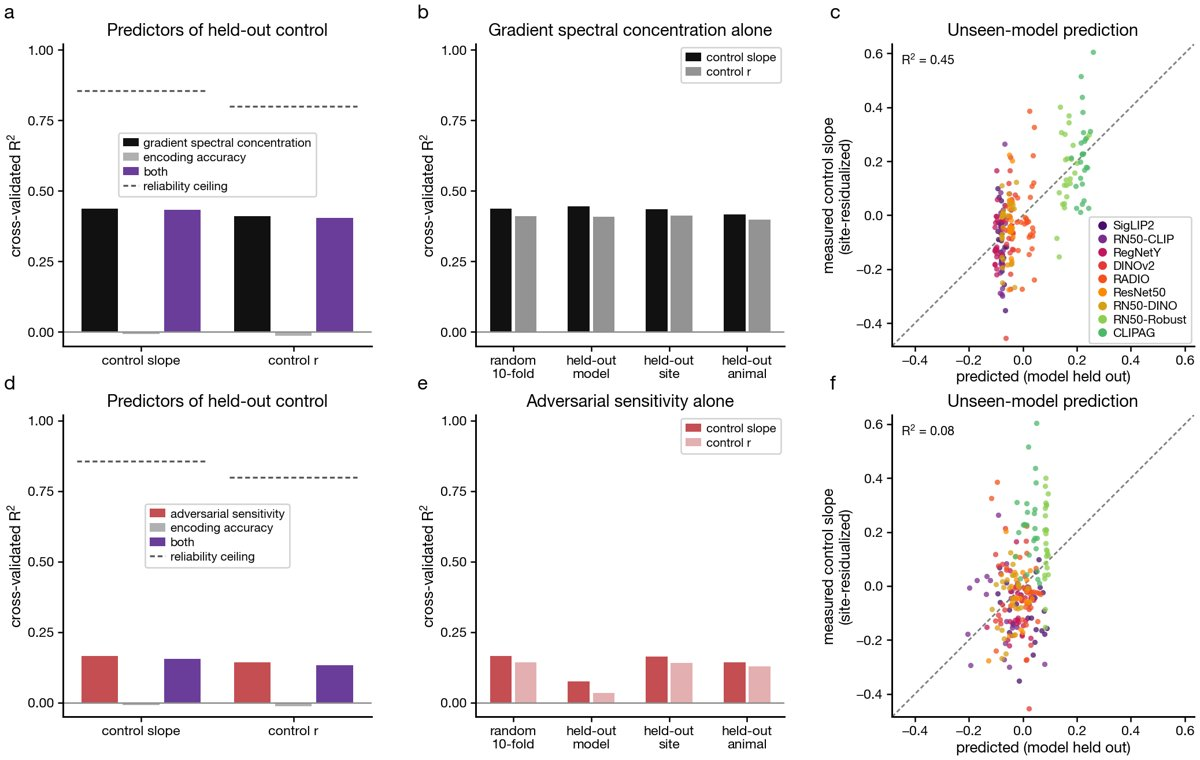

In [21]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S48. Cross-validated prediction of parametric control among the trained models.** What predicts held-out parametric control among the $9$ trained models ($225$ encoding axes): gradient spectral concentration (top row) versus adversarial sensitivity (bottom row), each against natural-image encoding accuracy. The untrained model is excluded as an out-of-distribution extreme that inflates every correlation and breaks leave-one-model-out evaluation on the site-residualized outcome. Outcomes are control slope and control $r$, each site-residualized against the per-site mean over the $9$ trained models. Predictors are the gradient spectral participation ratio on the $100$ held-out natural images, first-order adversarial sensitivity (both main-figure quantities), and the calibration-phase encoding validation $r$; models are ordinary least squares with a single global slope per predictor (the only design under which an unseen animal can be predicted at all), z-scored within each training fold. (A, D) $10$-fold cross-validated $R^2$ for the row's predictor alone, encoding accuracy alone, and both together, against the seed split-half explainable ceiling (dashed). (B, E) The row's predictor alone under progressively harder held-out regimes: random folds, whole held-out models, whole held-out sites, and whole held-out animals. (C, F) Measured versus predicted site-residualized control slope with the model itself held out (leave-one-model-out). Spectral PR generalizes across every held-out regime, whereas adversarial sensitivity and encoding accuracy do not.